# Project 5 :- Music Mood Prediction using ML 
#End-to-end Data Science + ML + AI (Streamlit Ready Project)

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


In [2]:
df = pd.read_csv("SpotifyFeatures.csv")

In [3]:
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [4]:
df.shape

(232725, 18)

In [5]:
df.columns

Index(['genre', 'artist_name', 'track_name', 'track_id', 'popularity',
       'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence'],
      dtype='object')

In [6]:
df.isnull().sum()

genre               0
artist_name         0
track_name          1
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
def get_mood(row):
    if row['valence'] >= 0.6 and row['energy'] >= 0.6:
        return 'Happy'
    elif row['valence'] <= 0.4 and row['energy'] <= 0.4:
        return 'Sad'
    elif row['energy'] >= 0.7:
        return 'Energetic'
    else:
        return 'Calm'

df['mood'] = df.apply(get_mood, axis=1)
df['mood'].value_counts()

mood
Calm         89566
Happy        50112
Energetic    48073
Sad          44974
Name: count, dtype: int64

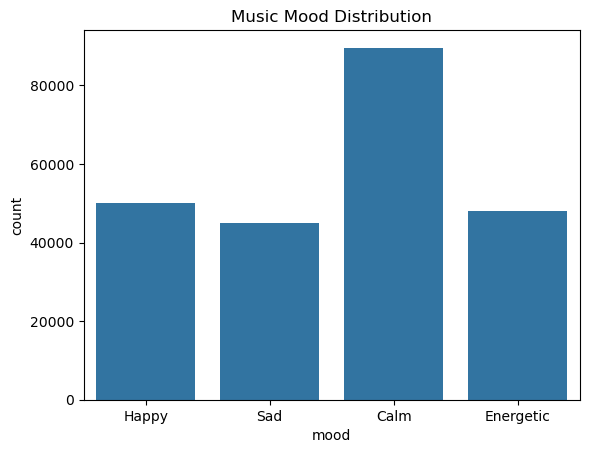

In [9]:
sns.countplot(x=df['mood'])
plt.title("Music Mood Distribution")
plt.show()

In [10]:
features = ['danceability', 'energy', 'loudness', 'tempo', 'valence']
X = df[features]
y = df['mood']

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17814
           1       1.00      1.00      1.00      9648
           2       1.00      1.00      1.00     10108
           3       1.00      1.00      1.00      8975

    accuracy                           1.00     46545
   macro avg       1.00      1.00      1.00     46545
weighted avg       1.00      1.00      1.00     46545



In [12]:
def predict_mood(danceability, energy, loudness, tempo, valence):
    input_data = np.array([[danceability, energy, loudness, tempo, valence]])
    prediction = model.predict(input_data)
    return le.inverse_transform(prediction)[0]

# test
predict_mood(0.8, 0.9, -5, 120, 0.7)


C:\Users\cxash\anaconda\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


'Happy'